In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# import sklearn as sk
# from sklearn.impute import SimpleImputer
import sqlite3 as sql

from ProceduralProgrammingModuleProject.DataModelling import ConvertBoolToInt
from SQLQueries import BaseQuery

con = sql.connect('studentperformance.db')
curs = con.cursor()

BaseData = pd.read_sql(BaseQuery, con=con)

BaseData

,StudentID,SchoolID,SchoolName,Sex,Age,AddressType,FamilySize,ParentLivingStatus,Commute,ReasonForSchoolChoice,...,GuardianTwoID,FathersOccupationID,FathersOccupation,FathersEducationLevel,IsFatherPrimary,IsMotherPrimary,PrimaryGuardian,ExamOneGrade,ExamTwoGrade,ExamThreeGrade
0,0,1,GP,F,18,U,GT3,A,15-30 minutes,course,...,649,5,teacher,4,0,1,Mother,0,11,11
1,1,1,GP,F,17,U,GT3,T,<15 minutes,course,...,650,3,other,1,1,0,Father,9,11,11
2,2,1,GP,F,15,U,LE3,T,<15 minutes,other,...,651,3,other,1,0,1,Mother,12,13,12
3,3,1,GP,F,15,U,GT3,T,<15 minutes,home,...,652,4,services,2,0,1,Mother,14,14,14
4,4,1,GP,F,16,U,GT3,T,<15 minutes,home,...,653,3,other,3,1,0,Father,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,644,2,MS,F,19,R,GT3,T,<15 minutes,course,...,1293,3,other,3,0,1,Mother,10,11,10
645,645,2,MS,F,18,U,LE3,T,<15 minutes,course,...,1294,4,services,1,0,1,Mother,15,15,16
646,646,2,MS,F,18,U,GT3,T,15-30 minutes,course,...,1295,3,other,1,0,1,Mother,11,12,9
647,647,2,MS,M,17,U,LE3,T,15-30 minutes,course,...,1296,4,services,1,0,1,Mother,10,10,10


Remove Redundant columns

In [28]:
StudentData = BaseData.drop(columns=['SchoolName', 'GuardianOneID', 'GuardianTwoID', 'FathersOccupation', 'MothersOccupation', 'PrimaryGuardian'])

Get column names

In [29]:
for col in StudentData.columns:
    print(col)

StudentID
SchoolID
Sex
Age
AddressType
FamilySize
ParentLivingStatus
Commute
ReasonForSchoolChoice
TimeSpentStudying
FailureCount
EducationalSupport
ParentalSupport
ReceivesTutoring
ExtraCurricular
AttendedNursery
PlansOnHigherEducation
HasInternet
InRelationship
FamilyRelationshipRating
BusynessScale
SocialScore
WeekdayAlcoholConsumption
WeekendAlcoholConsumption
HealthScore
AbsenceCount
MothersOccupationID
MothersEducationLevel
FathersOccupationID
FathersEducationLevel
IsFatherPrimary
IsMotherPrimary
ExamOneGrade
ExamTwoGrade
ExamThreeGrade


Identifying Non-Numeric Columns

In [30]:
def NonNumeric(Frame):
    NonNumericColumns = []
    StudentDict = Frame.to_dict('records')
    for key in StudentDict[0].keys():
        #Attemps to cast number as integer if this raises an error the column will be added to the list of non-numeric columns
        try:
            StudentDict[0][key] = int(StudentDict[0][key])
        except ValueError:
            NonNumericColumns.append(key)
    return NonNumericColumns

NumericCols = NonNumeric(StudentData)
print(NumericCols)

['Sex', 'AddressType', 'FamilySize', 'ParentLivingStatus', 'Commute', 'ReasonForSchoolChoice', 'TimeSpentStudying', 'EducationalSupport', 'ParentalSupport', 'ReceivesTutoring', 'ExtraCurricular', 'AttendedNursery', 'PlansOnHigherEducation', 'HasInternet', 'InRelationship']


Performing Data Transformations

In [34]:
from DataModelling import *
TransformedData = StudentData.apply(IsMale, axis=1)
TransformedData = TransformedData.apply(HasRuralAddress, axis=1)
TransformedData = TransformedData.apply(FamilySizeGreaterThanThree, axis=1)
TransformedData = TransformedData.apply(ParentsSeperated, axis=1)
TransformedData = TransformedData.apply(CommuteTimeGreaterThan, axis=1)
TransformedData = TransformedData.apply(ChoseSchoolFor, axis=1)
TransformedData = TransformedData.apply(StudyHoursGreaterThan, axis=1)
TransformedData = TransformedData.apply(ConvertBoolToInt, axis=1)
TransformedData = TransformedData.drop(columns=['Sex', 'AddressType', 'FamilySize', 'ParentLivingStatus', 'Commute', 'ReasonForSchoolChoice', 'TimeSpentStudying'])
#Applying all functions from DataModelling.py to my data

#Sanity check, making sure all data has been transformed as expected
print(NonNumeric(TransformedData)) #Should result in empty list
TransformedData.head()

[]


,StudentID,SchoolID,Age,FailureCount,EducationalSupport,ParentalSupport,ReceivesTutoring,ExtraCurricular,AttendedNursery,PlansOnHigherEducation,...,ExamThreeGrade,IsMale,IsRuralAddress,FamilySizeGreaterThanThree,ParentsSeperated,CommuteTimeGreaterThan,ChoseSchoolForCourse,ChoseSchoolForReputation,ChoseSchoolForProximity,StudyHoursGreaterThan
0,0,1,18,0,1,0,0,0,1,1,...,11,0,0,1,1,15,1,0,0,2
1,1,1,17,0,0,1,0,0,0,1,...,11,0,0,1,0,0,1,0,0,2
2,2,1,15,0,1,0,0,0,1,1,...,12,0,0,0,0,0,0,0,0,2
3,3,1,15,0,0,1,0,1,1,1,...,14,0,0,1,0,0,0,0,1,5
4,4,1,16,0,0,1,0,0,1,1,...,13,0,0,1,0,0,0,0,1,2


Find Correlation Between Columns

<Axes: >

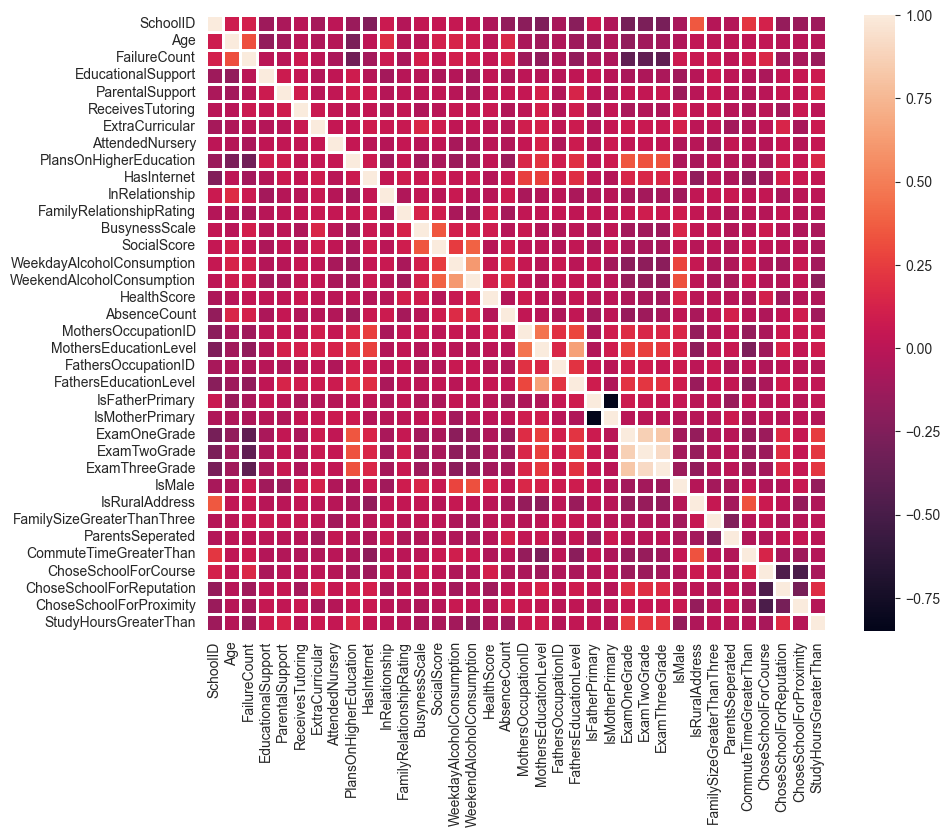

In [57]:
Correlation = TransformedData.drop(columns=['StudentID']).corr(numeric_only=True)
plt.figure(figsize = (10,8))
corr_heatmap = sns.heatmap(Correlation, linewidths=1)
corr_heatmap
#From This you can see that ExamTwoGrade has the greatest impact on ExamThreeGrade followed by ExamOneGrade
#The columns PlansOnHigherEducation also holds some weight on ExamThreeGrade as well as TheStudyHoursGreaterThan column showing students who studying more typically achieve a higher grade 